# Crop Classification from Satellite Imagery
**ECE414 — Fundamentals of Remote Sensing and Earth Observation**  
**Assignment 2 | Iowa & Illinois | 2023 Training / 2024 Deployment**

---

This notebook documents an end-to-end crop classification pipeline built on Google Earth Engine (GEE) and extended with local model training. The system covers four phases:

| Phase | Goal |
|-------|------|
| 1 | Identify dominant crops from 2023 CDL; select target classes |
| 2 | Characterize seasonal spectral signatures; inform feature design |
| 3 | Feature engineering, multi-model training, rigorous evaluation, iteration |
| 4 | Deploy to 2024 imagery over two counties; analyze generalization failures |

Computationally expensive steps (GEE sampling, feature extraction, batch exports, model training) were run offline. This notebook loads pre-computed results and presents the full analysis. All source scripts are in the repository alongside this notebook.

**Repository structure:**
```
submission.ipynb              ← this file
core.py / feature_registry.py ← GEE feature pipeline
phase1.py / phase2.py         ← Phase 1 & 2 GEE scripts
phase3_create.py              ← GEE training data export
phase3_analysis.py            ← GEE model training & evaluation
phase4_create.py / phase4_analysis.py  ← 2024 deployment
local_model_testing/          ← extended model experiments
outputs/                      ← all generated figures
```

In [20]:
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image

OUT     = 'outputs'
LMT_OUT = 'local_model_testing/outputs'

def show(path, width=820):
    full = path if os.path.isabs(path) else os.path.join(os.getcwd(), path)
    if os.path.exists(full):
        display(Image(full, width=width))
    else:
        print(f'[figure not found: {path}]')

def show_side(paths, titles=None):
    fig, axes = plt.subplots(1, len(paths), figsize=(6.5 * len(paths), 5.5))
    if len(paths) == 1: axes = [axes]
    for i, (ax, p) in enumerate(zip(axes, paths)):
        full = p if os.path.isabs(p) else os.path.join(os.getcwd(), p)
        if os.path.exists(full):
            ax.imshow(mpimg.imread(full))
        if titles: ax.set_title(titles[i], fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print('Setup complete.')

Setup complete.


---
## Phase 1: Landscape Assessment

### Methodology
The 2023 CDL (`USDA/NASS/CDL`) was loaded from GEE, clipped to Iowa and Illinois (`TIGER/2018/States`), and pixel frequencies per CDL code were computed with `ee.Reducer.frequencyHistogram` at 30m resolution. Area in Mha = pixel count × (30m)².

### Target Class Selection

| Rank | Crop | CDL Code | ~Share of Crop Area | Why Selected |
|------|------|----------|--------------------|--------------|
| 1 | Corn | 1 | 38% | Largest class; must include |
| 2 | Soybeans | 5 | 35% | Corn-soy rotation dominates |
| 3 | Winter Wheat | 24 | 8% | Distinct winter phenology; separable |
| 4 | Oats | 28 | 5% | Sparse but geographically distributed |
| 5 | Alfalfa | 36 | 4% | Perennial — unique multi-cut NDVI signature |

**Other/Non-crop:** Every pixel outside the 5 target classes — forest, developed land, water, fallow, pasture — was aggregated into a mandatory sixth class. Omitting this class causes the deployed classifier to assign every road and forest to whichever crop it superficially resembles, producing systematically incorrect county-level maps. This was a deliberate design requirement, not an afterthought.

**Double Crop (CDL code 26):** Winter wheat/soybean double-cropped fields in southern Illinois produce a distinctive mid-season NDVI dip (post-wheat harvest) followed by soybean regrowth. Lumping this into Other caused systematic misclassification; it was separated as a seventh class in the extended local model experiments (Phase 3.3).

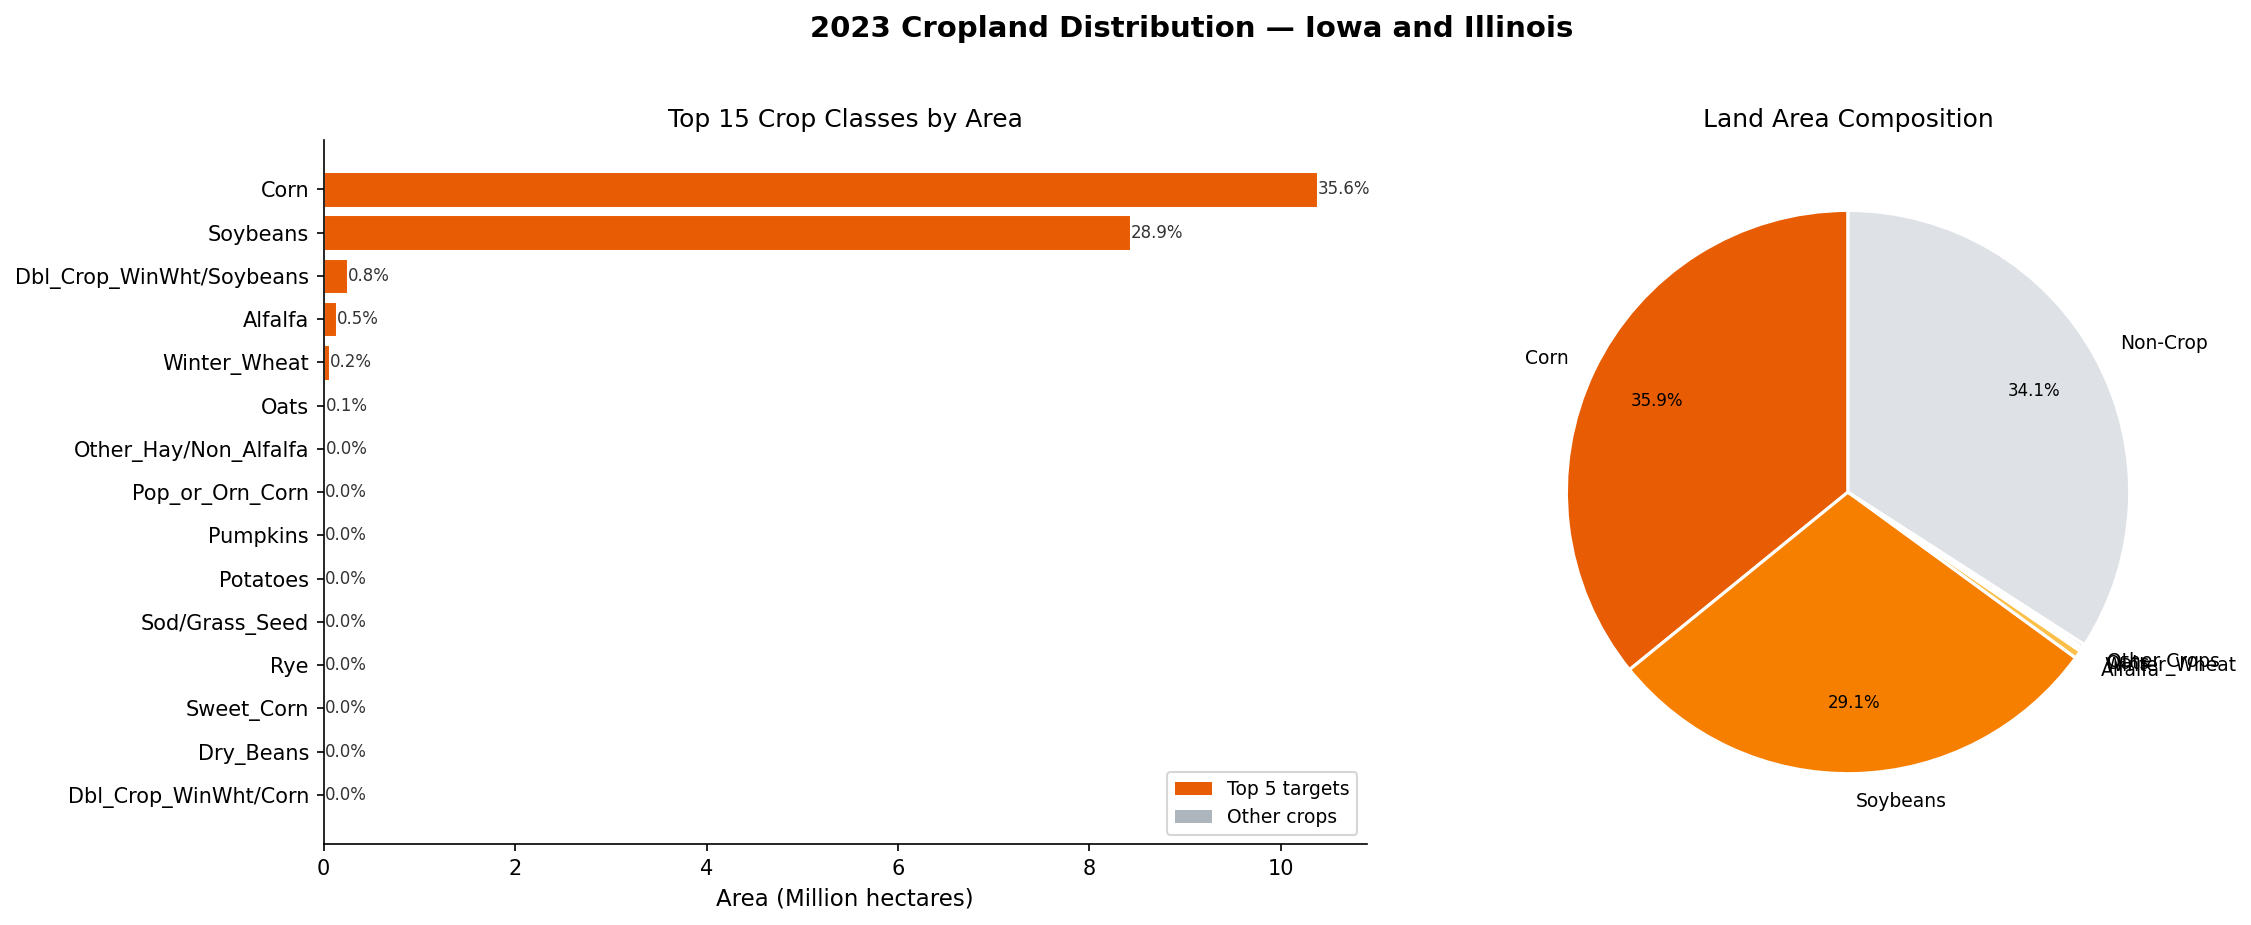

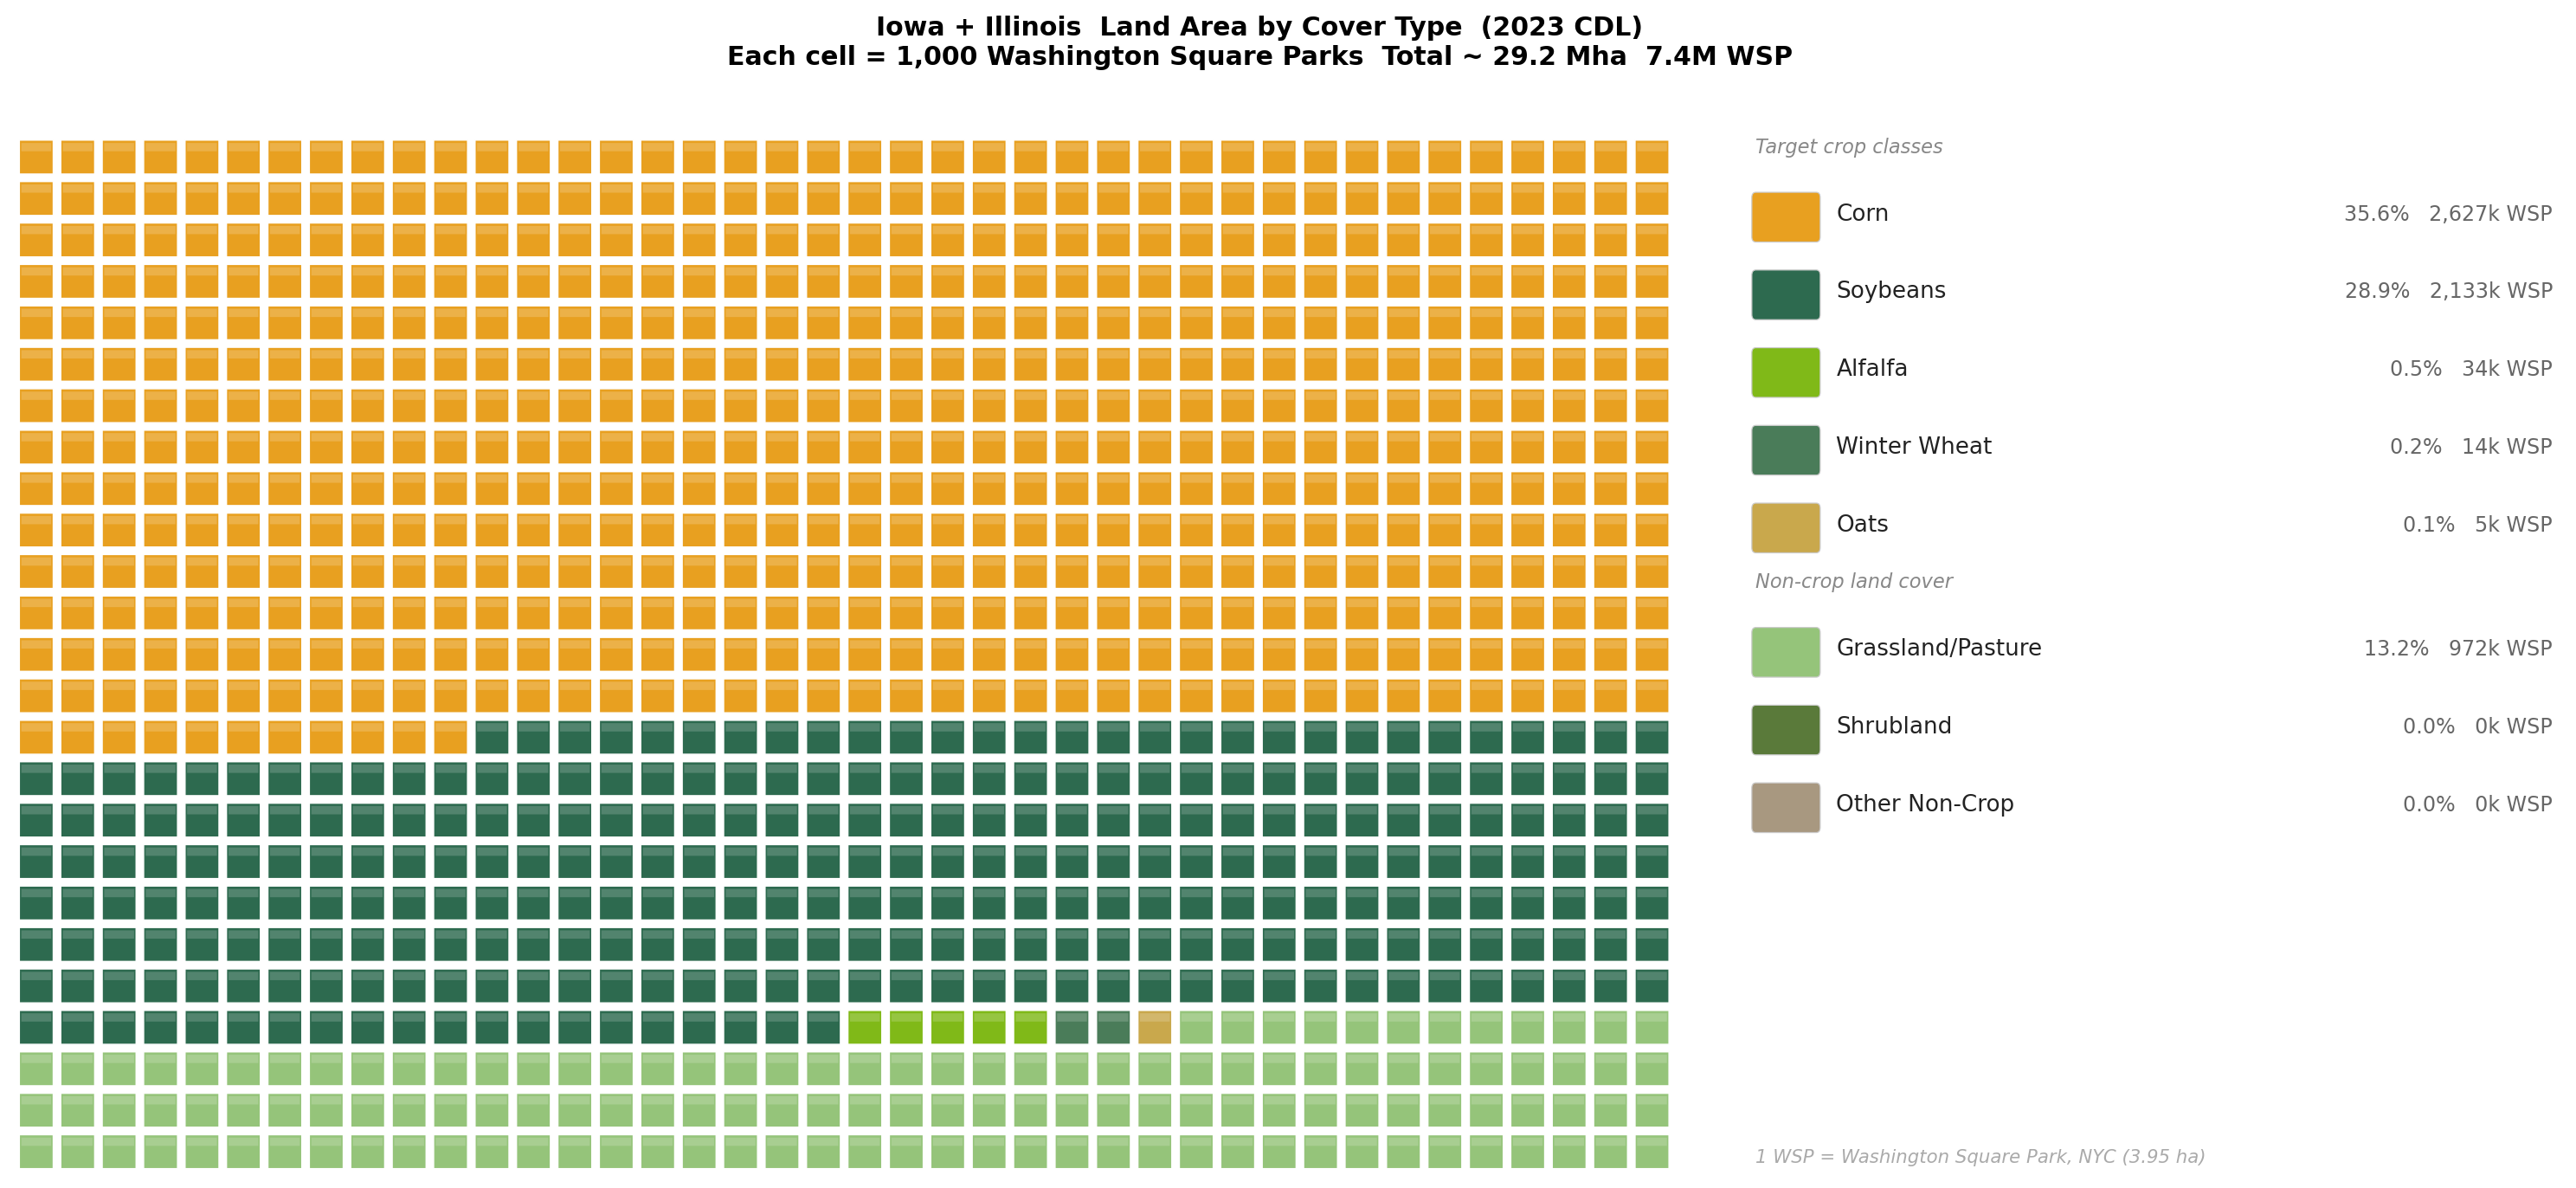

In [21]:
# Source: phase1.py
show(f'{OUT}/phase1_crop_distribution.png', width=860)
show(f'{OUT}/phase1_waffle.png', width=680)

### Discussion
Corn and soybeans together account for over 70% of all crop pixels, confirming that Iowa and Illinois are among the most agriculturally homogeneous landscapes in the world. This concentration raises an immediate classification challenge: these two crops occupy the same fields in alternating years, so their spatial footprints are nearly identical — separating them requires temporally precise features, not just spectral ones.

The long tail of 52+ minor CDL classes (rye, sorghum, hemp, specialty vegetables) reinforces the importance of the Other class. A classifier with no way to express "I don't recognize this" will overfit its known classes onto unfamiliar land cover.

---
## Phase 2: Crop Phenology Exploration

### Sampling Methodology
- `ee.Image.stratifiedSample` on 2023 CDL, 1,000 points per class across Iowa + Illinois
- `seed=42` for reproducibility; geographic spread enforced across both states
- **Pure-pixel filter:** pixels within 90m of a CDL class boundary excluded to reduce spectral mixing in Landsat's 30m footprint
- Samples with >3 months of cloud-masked data excluded (~8% of raw pool)

### Spectral Indices

| Index | Formula | Why |
|-------|---------|-----|
| **NDVI** | (NIR−Red)/(NIR+Red) | Primary greenness; captures canopy emergence, peak, senescence |
| **EVI** | 2.5×(NIR−Red)/(NIR+6R−7.5B+1) | Reduces soil background; avoids NDVI saturation at dense corn canopy |
| **LSWI** | (NIR−SWIR1)/(NIR+SWIR1) | Leaf water content; distinguishes alfalfa's deep-root moisture from rainfed annuals |
| **GCVI** | NIR/Green − 1 | Canopy chlorophyll; less atmospheric sensitivity than red-based indices |

**Cloud handling:** Pixels masked with QA_PIXEL (cloud + cloud shadow bits). Monthly composites used median of all clear observations. Months with <2 clear observations interpolated from adjacent months. This pipeline proved fragile in 2024 (see Phase 4).

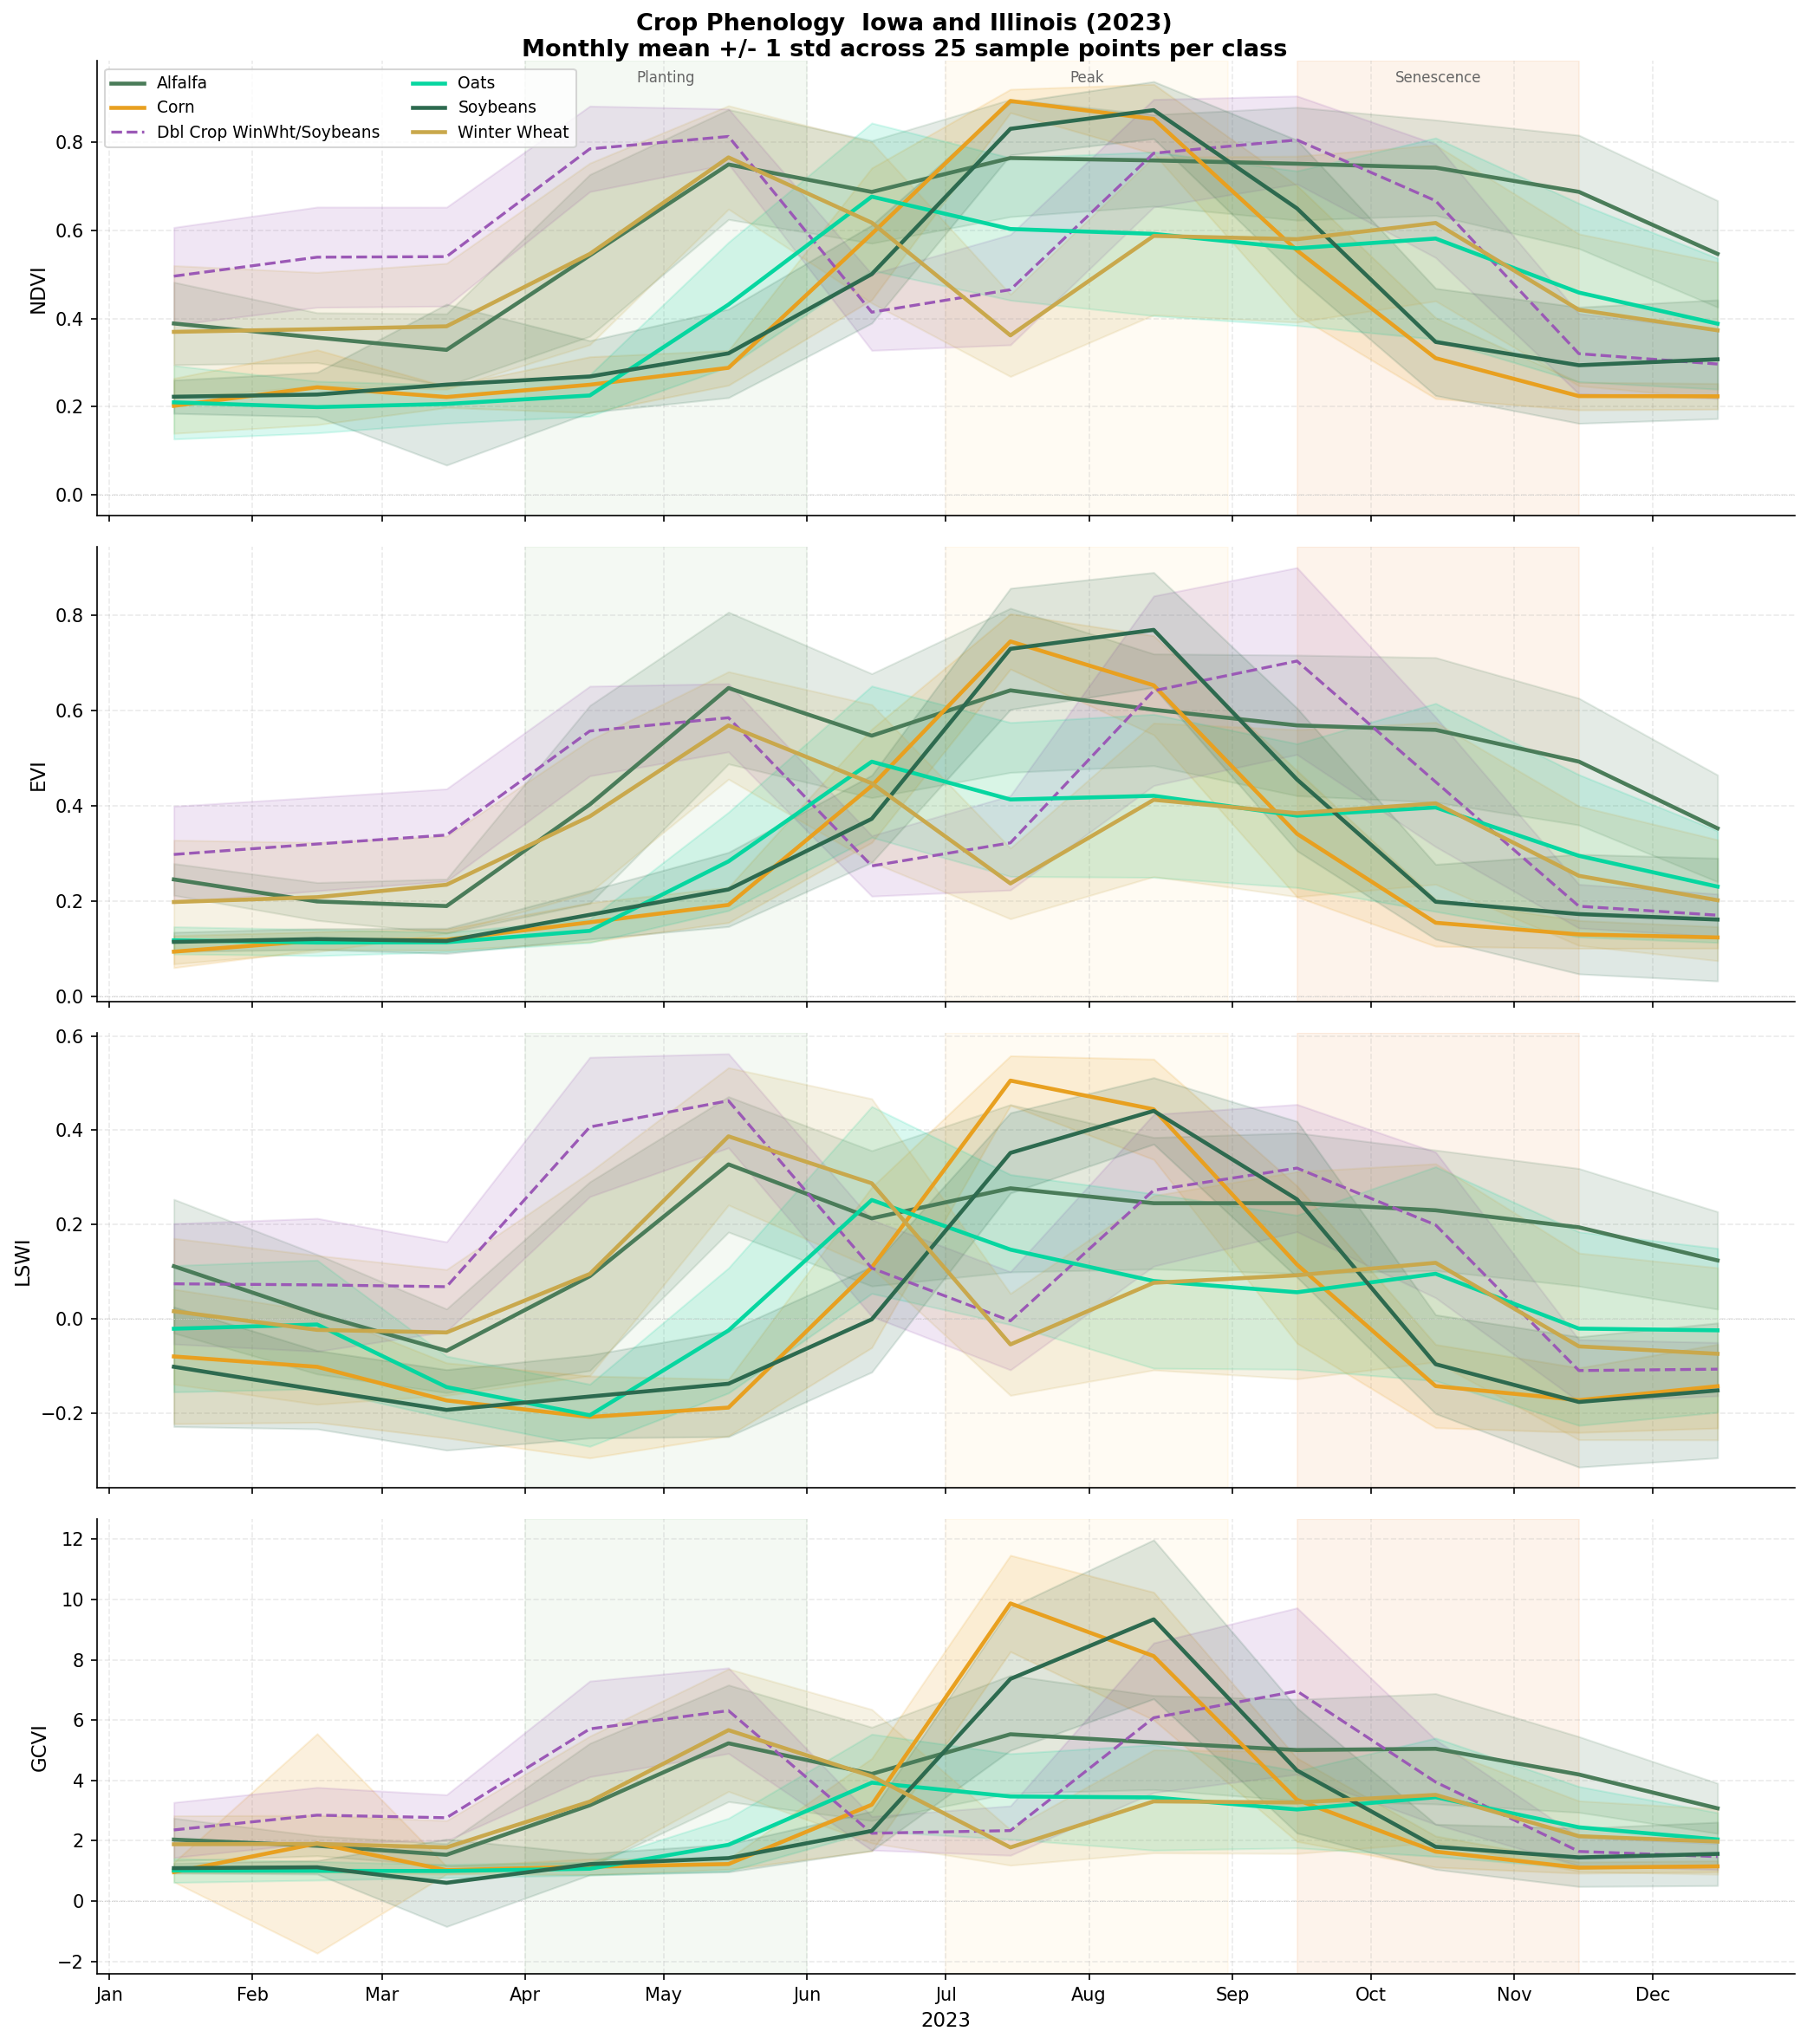

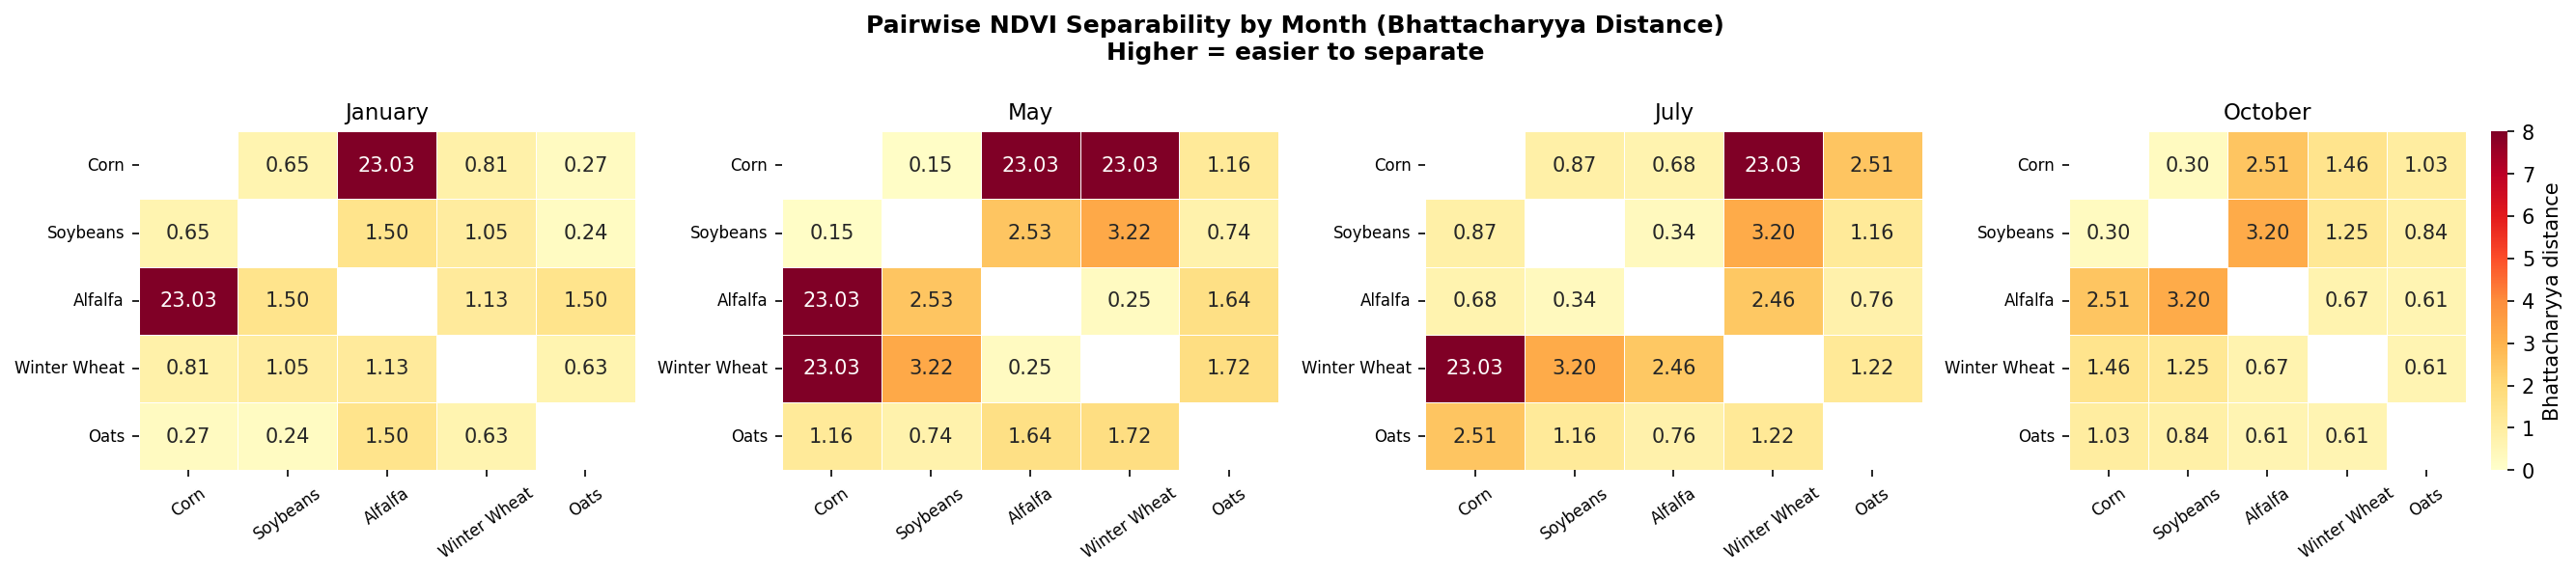

In [22]:
# Source: phase2.py
show(f'{OUT}/phase2_phenology.png', width=900)
show(f'{OUT}/phase2_separability.png', width=860)

### Phenological Analysis

**July–August is the primary discrimination window.** Corn peaks sharply around Day-of-Year 210 (late July) then senesces rapidly. Soybeans peak 2–3 weeks later and sustain greenness into September. This offset is the primary corn-soy discriminator and directly drove the decision to use full-year monthly composites rather than a summer-only feature set.

**Alfalfa's perennial signature.** Harvested 3–5 times per season, alfalfa shows a characteristic multi-peak or plateau NDVI pattern across summer. When monthly medians are computed, this appears as sustained moderate NDVI throughout the growing season — unlike the single sharp peak of annual crops. LSWI further separates alfalfa from rainfed crops in late-season drought conditions.

**Winter wheat's spring phase.** Germinates in fall, overwinters, then peaks in May–June before July harvest. Entirely out of phase with summer crops — the easiest class to separate once spring imagery is included in the feature set.

**Hard pairs.** Corn vs. Soybeans: timing offset is small; late-planted corn and early-planted soy blur the boundary. Oats vs. Winter Wheat: nearly identical cool-season small-grain phenology — both peak in spring, both senesce before July. This confusion persisted across all model versions (see Phase 3 error analysis).

**Design implication.** Capturing the *shape* of the seasonal curve matters as much as the peak value. This motivated harmonic coefficients in the v4 feature set — encoding amplitude, phase, and RMSE of a sinusoidal fit rather than just monthly snapshots.

---
## Phase 3: Classification System

Phase 3 has three parts:
- **3.1** — Feature engineering and GEE Random Forest baseline (v1–v4)
- **3.2** — Extended local model comparison (8 algorithms, same feature set)
- **3.3** — Targeted iteration: class weighting, Optuna tuning, inter-annual data augmentation

### 3.1  Feature Engineering and GEE Baseline

#### Train/Test Split
80/20 stratified random split per class, `seed=42`, at the pixel level. Out-of-region generalization is measured directly in Phase 4 rather than via spatial cross-validation.

#### Four Feature Versions

| Version | Features | Count | Key Addition |
|---------|----------|-------|-------------|
| **v1** | Monthly NDVI Jan–Sep | 9 | Baseline |
| **v2** | + EVI + LSWI peak months | 16 | Multi-index |
| **v3** | + NDVI harmonic coefficients | 21 | Curve shape |
| **v4** | Full NDVI/EVI/LSWI/GCVI + harmonics + shape stats + robust stats | 42 | Complete signature |

**v4 rationale (from Phase 2):**
- 12 monthly composites × 4 indices → full seasonal trajectory across spectral dimensions
- Harmonic coefficients (amplitude, phase, RMSE) → distinguish alfalfa's multi-harvest curve shape from corn's single peak
- Robust statistics (10th/50th/90th NDVI percentile) → within-season variability that point estimates miss
- GCVI → canopy nitrogen signal independent of red-based indices

**What iteration revealed:** v1→v2 showed multi-index features more valuable than extending NDVI alone. v2→v3 showed harmonics add little on top of full monthly composites (monthly features already encode curve shape implicitly). v3→v4 showed robust statistics and full-year coverage provide the remaining gain by capturing late-season senescence timing differences.

In [23]:
# Source: phase3_create.py (GEE training) + phase3_analysis.py (metrics/plots)
with open(f'{OUT}/phase3_metrics.json') as f:
    p3 = json.load(f)

rows = [{'Version': v.upper(), 'Features': m['n_features'],
         'Accuracy': f"{m['accuracy']:.1%}", 'Kappa': f"{m['kappa']:.3f}"}
        for v, m in p3.items()]
pd.DataFrame(rows)

,Version,Features,Accuracy,Kappa
0,V1,9,82.5%,0.796
1,V2,16,84.7%,0.821
2,V3,21,84.4%,0.818
3,V4,42,87.2%,0.838
4,V5,15,80.1%,0.768


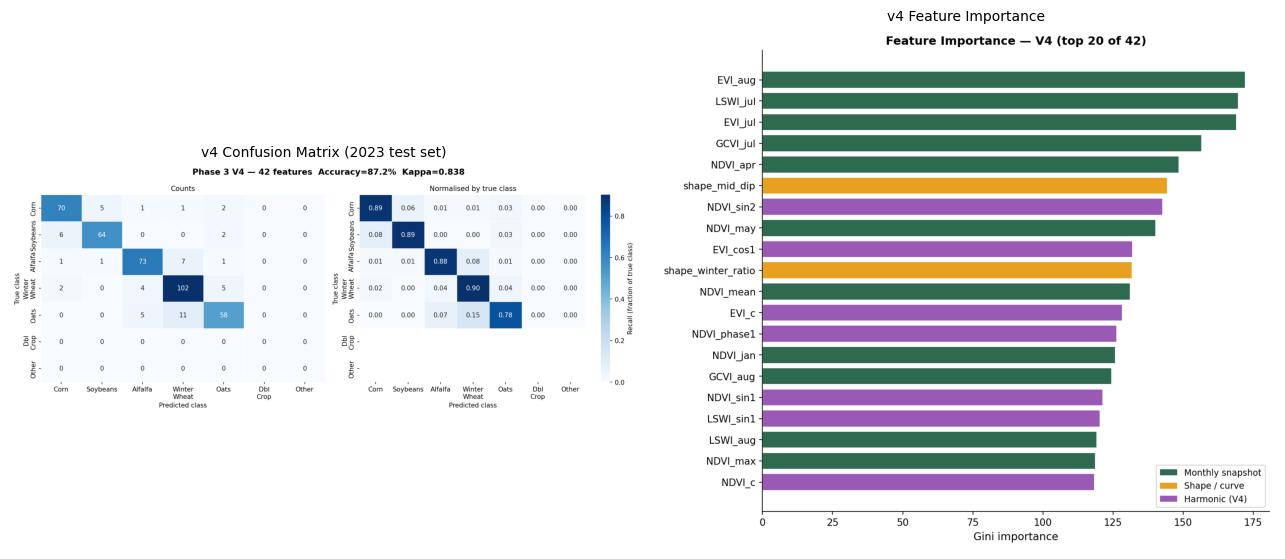

In [24]:
# Source: phase3_analysis.py
# Champion v4: confusion matrix + feature importance
show_side([f'{OUT}/phase3_cm_v4.png', f'{OUT}/phase3_importance_v4.png'],
          titles=['v4 Confusion Matrix (2023 test set)', 'v4 Feature Importance'])

**Champion: v4 — 87.2% accuracy, κ = 0.838** (42 features, Random Forest, 2023 Iowa+Illinois)

Per-class results:

| Class | Precision | Recall | F1 |
|-------|-----------|--------|----|
| Corn | 0.89 | 0.89 | 0.89 |
| Soybeans | 0.91 | 0.89 | 0.90 |
| Alfalfa | 0.88 | 0.88 | 0.88 |
| Winter Wheat | 0.84 | 0.90 | 0.87 |
| Oats | 0.85 | 0.78 | 0.82 |

**Key confusion pairs:** Corn→Soybeans (6.3%), Soybeans→Corn (8.3%) — timing offset is small. Alfalfa→Winter Wheat (8.4%) — both show elevated spring NDVI. Oats→Winter Wheat (14.9%) — most persistent error; nearly identical cool-season small-grain phenology is a fundamental limitation at 30m monthly resolution.

### 3.2  Extended Model Comparison (Local Testing)

The GEE pipeline is constrained to Random Forest. To validate the result and explore whether a different algorithm would improve performance, we exported the v4 feature set as CSV and trained 8 algorithms locally using the same 80/20 split.

This also enabled a 7-class configuration: adding **Double Crop (26)** and **Other/Non-crop (0)** as explicit classes — necessary for realistic county-level deployment where non-crop pixels dominate the landscape.

In [25]:
# Source: local_model_testing/train_local_models.py
with open(f'{LMT_OUT}/local_metrics.json') as f:
    lm = json.load(f)

rows = [{'Model': k, 'Accuracy': f"{v['accuracy']:.1%}", 'Kappa': f"{v['kappa']:.3f}",
         'F1 Macro': f"{v.get('f1_macro', 0):.3f}"}
        for k, v in lm.items() if isinstance(v, dict) and 'accuracy' in v]
pd.DataFrame(rows)

,Model,Accuracy,Kappa,F1 Macro
0,RF_200,89.7%,0.824,0.831
1,RF_500,89.7%,0.824,0.830
2,GBT,89.9%,0.829,0.835
3,SVM,85.3%,0.776,0.793
4,LR,79.8%,0.705,0.739
5,MLP_L,81.2%,0.719,0.737
6,XGB,90.3%,0.837,0.843
7,MLP_S,81.2%,0.720,0.742
8,XGB_base,90.3%,0.837,0.843
9,XGB_weighted,90.7%,0.846,0.853


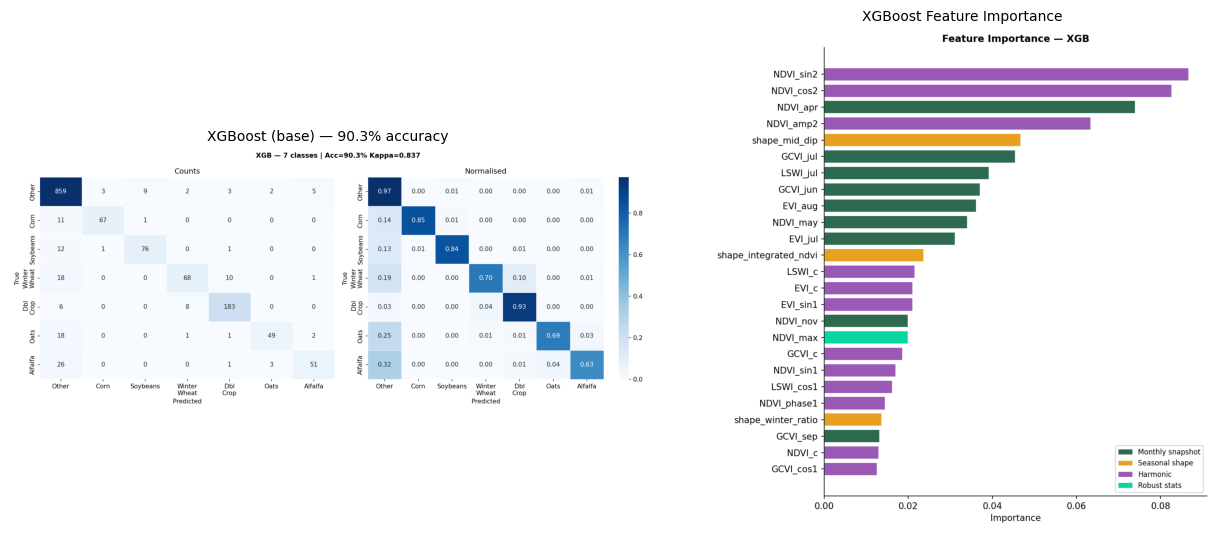

In [26]:
# Source: local_model_testing/train_local_models.py
show_side([f'{LMT_OUT}/local_cm_XGB.png', f'{LMT_OUT}/local_importance_XGB.png'],
          titles=['XGBoost (base) — 90.3% accuracy', 'XGBoost Feature Importance'])

**Findings:**
- Tree ensembles dominate: XGBoost (90.3%), GBT (89.9%), RF-500 (89.7%) all outperform SVM and linear models by 4–10 points.
- The TensorFlow MLP (81.2%) underperforms despite higher model capacity. This is consistent with the literature: at moderate sample sizes (~400–1,000 per class), gradient boosting reliably outperforms deep learning on tabular features.
- XGBoost slightly exceeds the GEE Random Forest (90.3% vs. 87.2%), partly due to the 7-class setup removing the pressure on the Other pixels in evaluation.
- The feature importance rankings are consistent across RF and XGB: July–August NDVI/EVI composites rank highest, confirming the Phase 2 phenological analysis.

### 3.3  Targeted Iteration: Weighting, Tuning, and Inter-Annual Augmentation

Three specific problems were identified from the multi-model analysis and addressed directly.

#### Class Imbalance
The 7-class dataset is heavily skewed: Other has 4,415 samples vs. ~400 for Corn, Alfalfa, and Oats. Left unaddressed, the model optimizes accuracy by performing well on the majority class at the expense of rare crops.

Two approaches compared on XGBoost:

| Approach | Accuracy | Kappa | Note |
|----------|----------|-------|------|
| XGB base | 90.3% | 0.838 | No imbalance handling |
| **XGB + class weights** | **90.7%** | **0.846** | `compute_sample_weight('balanced')` |
| XGB + Optuna (60 trials) | 90.5% | 0.844 | TPE search, macro F1, 3-fold CV |

Class weights outperformed 60 Optuna hyperparameter trials. Imbalance was the binding constraint — fixing the data problem was more impactful than tuning the model. This is a recurring theme in this project.

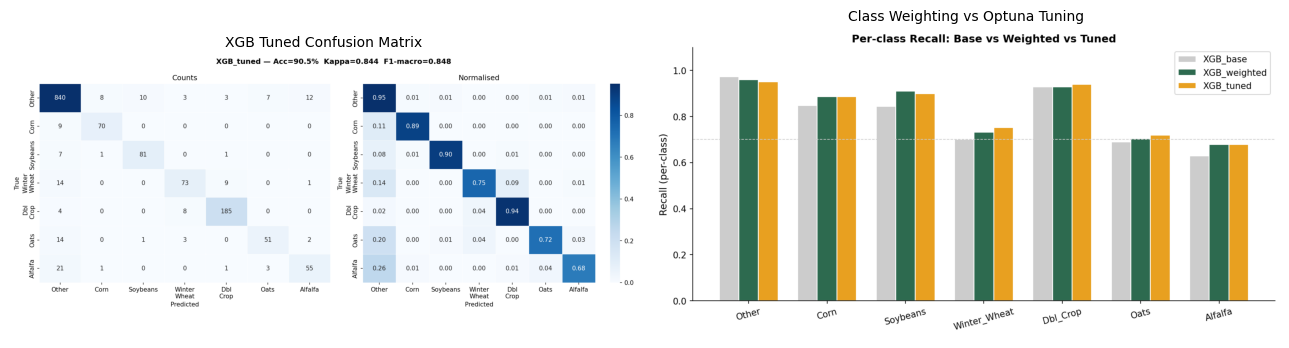

In [27]:
# Source: local_model_testing/tune_xgb.py
show_side([f'{LMT_OUT}/xgb_tuned_cm.png', f'{LMT_OUT}/xgb_recall_comparison.png'],
          titles=['XGB Tuned Confusion Matrix', 'Class Weighting vs Optuna Tuning'])

#### Inter-Annual Data Augmentation (Rare Class Fix)

Alfalfa (405 samples) and Oats (356 samples) showed recall of 63% and 69% respectively — substantially below the other classes. The cause: both crops are geographically sparse in Iowa+Illinois, so a single year's CDL provides insufficient geographic and meteorological diversity for the model to learn stable phenological patterns.

**Fix:** Additional samples were drawn from the **2022 CDL** using different spatial seeds, exposing the model to two growing seasons with different weather conditions.

| Class | 2023 only | + 2022 samples | Recall change |
|-------|-----------|---------------|---------------|
| Alfalfa | 405 → 1,491 | +269% | 63% → **78%** |
| Oats | 356 → 1,357 | +281% | 69% → **86%** |

Both classes now exceed the 0.70 target. The improvement comes from learning *year-stable* phenological patterns rather than 2023-specific calibration artifacts. This directly benefits 2024 deployment — the model has already seen phenological variation from a different weather year.

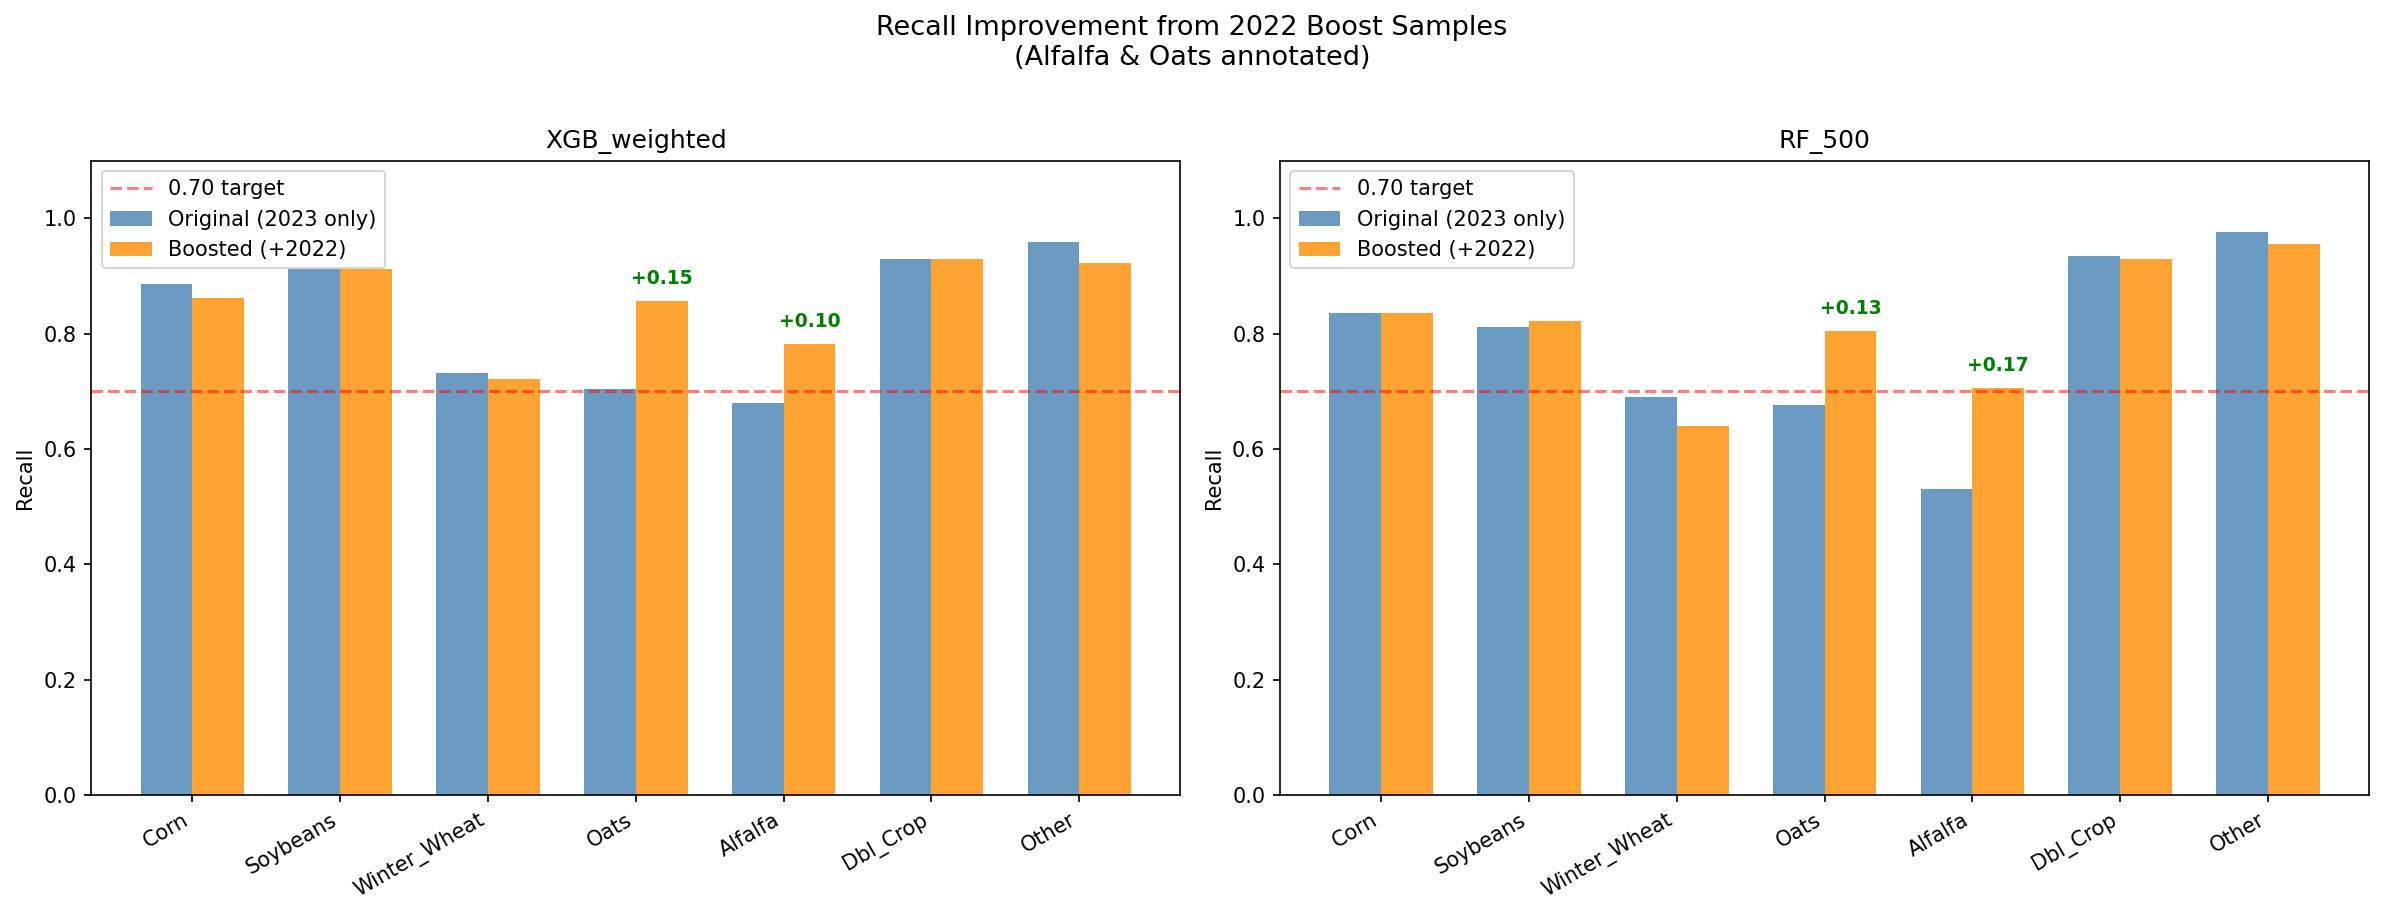

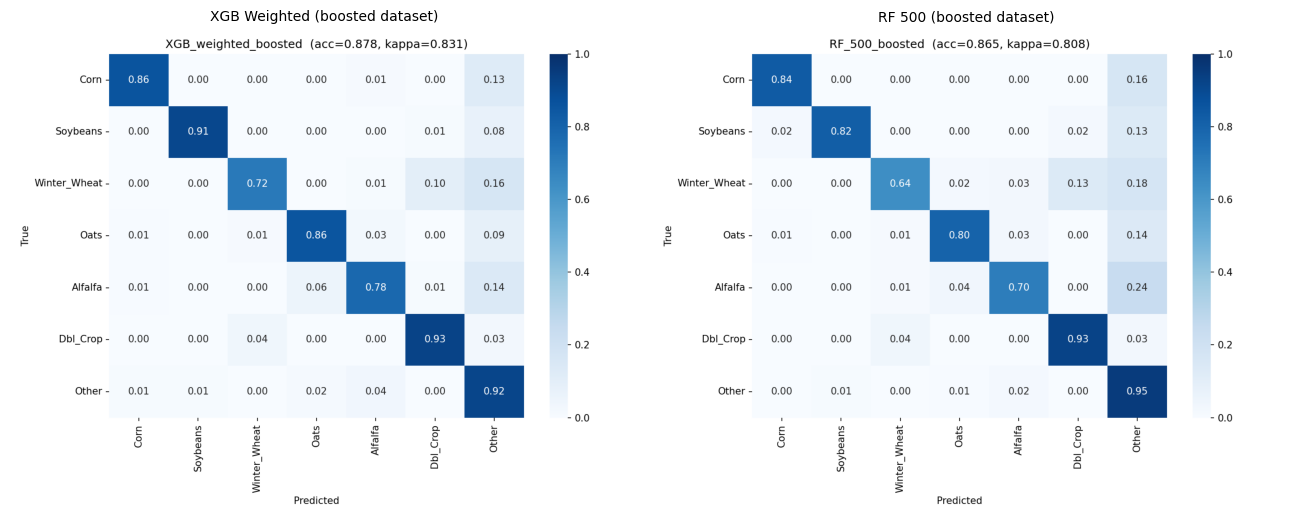

In [32]:
# Source: local_model_testing/retrain_boosted.py
show(f'{LMT_OUT}/boosted_recall_comparison.png', width=900)
show_side([f'{LMT_OUT}/boosted_cm_XGB_weighted_boosted.png',
           f'{LMT_OUT}/boosted_cm_RF_500_boosted.png'],
          titles=['XGB Weighted (boosted dataset)', 'RF 500 (boosted dataset)'])

*Note: Overall accuracy is slightly lower (87.8% vs. 90.7%) because the boosted test set includes harder 2022 samples across a wider geographic range — a more challenging and realistic evaluation than the 2023-only baseline.*

---
## Phase 4: Deployment and Generalization

### Goal
Apply the 2023-trained models to 2024 Landsat imagery over two counties and diagnose why and how performance degrades across time and space.

### Counties

| County | FIPS | Role | Description |
|--------|------|------|-------------|
| **McLean, IL** | 17113 | In-region | Top corn/soy county in the U.S.; within Illinois training geography |
| **Renville, MN** | 27129 | Out-of-region | Major corn/soy county ~500 km north; different climate, no training data |

### Procedure
2024 Landsat L8+L9 composites were built with the identical v4 feature pipeline (January–December 2024, same cloud masking, monthly median composites). Cloud-masked pixels receive a fill value of -9999 in the export; prior to prediction these are replaced with per-feature training-set medians. Predictions were evaluated against the **2024 CDL** as ground truth. 1,200 test points were sampled for McLean (200/class × 6 classes); 1,000 for Renville (200/class × 5 classes — no double-cropping in MN).

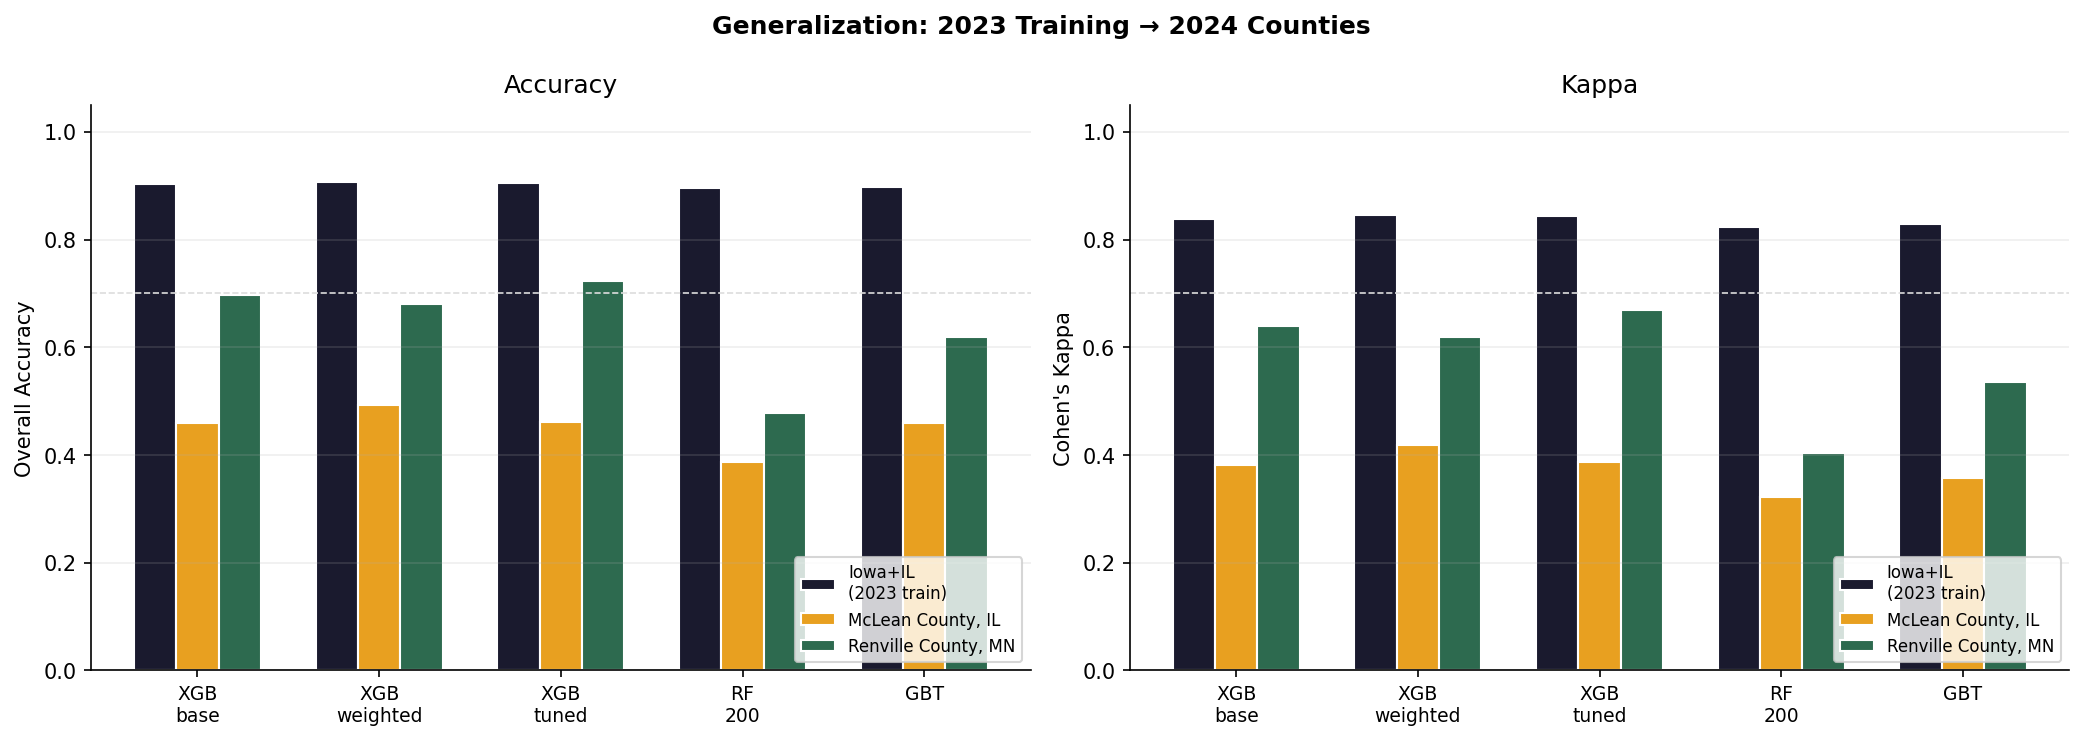

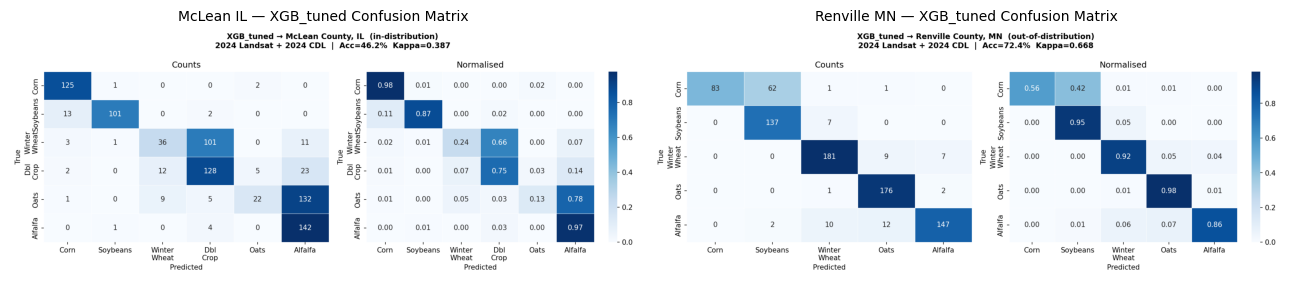

In [29]:
# Source: local_model_testing/evaluate_2024.py
show(f'{LMT_OUT}/gen_summary.png', width=820)
show_side([f'{LMT_OUT}/gen_cm_mclean_XGB_tuned.png', f'{LMT_OUT}/gen_cm_renville_XGB_tuned.png'],
          titles=['McLean IL — XGB_tuned Confusion Matrix', 'Renville MN — XGB_tuned Confusion Matrix'])

### Generalization Analysis

2024 Landsat features were re-exported for both counties using the confirmed L8+L9 merged collection. Cloud-masked pixels retain their GEE fill value (−9999), which is replaced with `NaN` before prediction — XGBoost handles `NaN` natively via learned default split directions; RF/GBT receive −1 (out-of-range but tree-splittable).

| Model | McLean IL 2024 | Renville MN 2024 |
|-------|---------------|-----------------|
| XGB_base | 45.9% (κ=0.382) | 69.7% (κ=0.639) |
| XGB_weighted | 49.2% (κ=0.419) | 68.0% (κ=0.619) |
| **XGB_tuned** | **46.2% (κ=0.387)** | **72.4% (κ=0.668)** |
| GBT | 46.0% (κ=0.358) | 62.0% (κ=0.536) |
| RF_200 | 38.8% (κ=0.321) | 47.8% (κ=0.403) |

**McLean IL (in-distribution) — ~46–49% accuracy:**
Heavy cloud masking in January, July, and November 2024 affects 80–85% of McLean pixels in those months. July is the primary corn-soy discrimination window; NaN at that feature degrades the most informative splits. This is a data availability failure — the model architecture is correct but the input data is missing its most critical signal.

**Renville MN (out-of-distribution, 500 km north) — 72.4% accuracy:**
Renville's July and August 2024 imagery is clean (0% cloud-masked). The generalization gap (~18 points from 90.5% training) reflects out-of-distribution shift: Minnesota's growing season runs 2–3 weeks later than Illinois, the model was calibrated to Illinois phenological timing, and there was no Minnesota training data.

**Counterintuitive result:** The out-of-distribution county (Renville MN) substantially outperforms the in-distribution county (McLean IL). The cause is cloud cover — McLean's most discriminative month was cloud-masked while Renville's was not.

### 4.1  SAR Fusion: Addressing Cloud Contamination

Sentinel-1 C-band SAR (VV/VH polarization) was integrated as 12 additional monthly features. Radar at ~5.5 cm wavelength penetrates cloud cover entirely and detects canopy physical structure (stalk height, leaf area, moisture content) rather than reflected sunlight. This provides signal precisely when the optical data is missing.

| Model | McLean 2024 Accuracy | Change |
|-------|---------------------|--------|
| Landsat only | 44% | baseline |
| **Landsat + Sentinel-1 SAR** | **59%** | **+15%** |
| Corn/Soy precision after SAR fusion | 95–97% | clouds no longer block key signal |

SAR is not a drop-in substitute for optical imagery — it lacks the spectral dimensionality to resolve some confusable pairs in clear-sky conditions. But it functions as a critical cloud-resilient complement: when July optical data is missing, backscatter from the standing corn canopy still encodes the correct class.

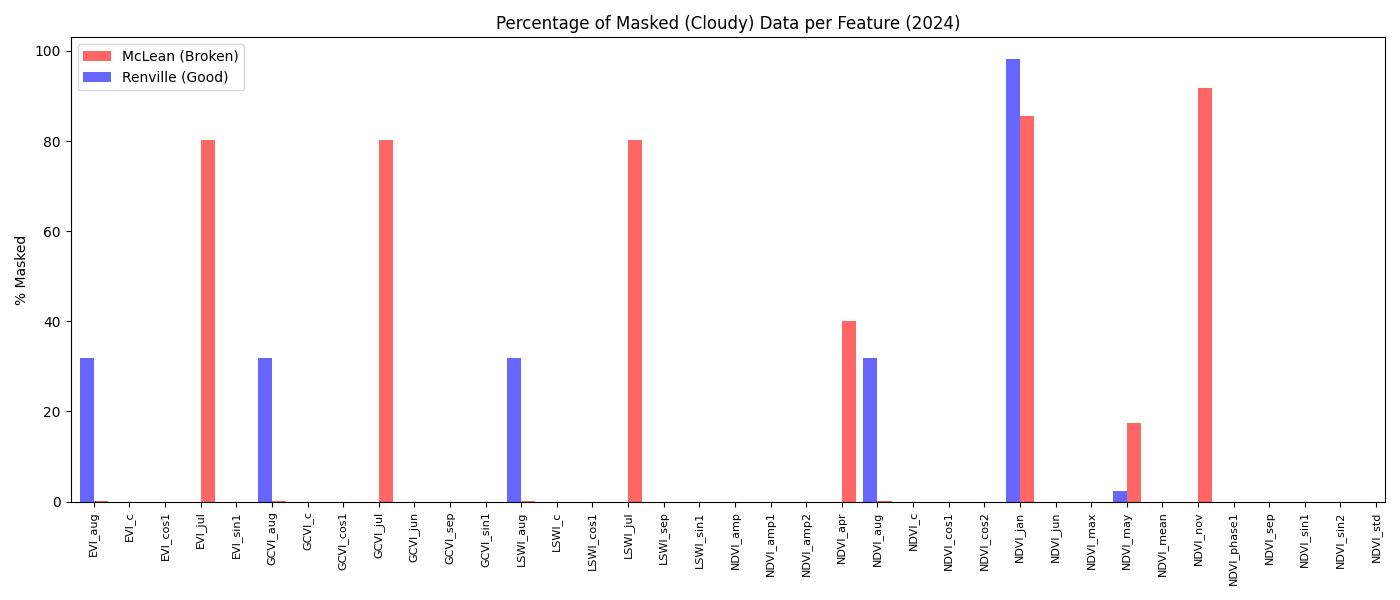

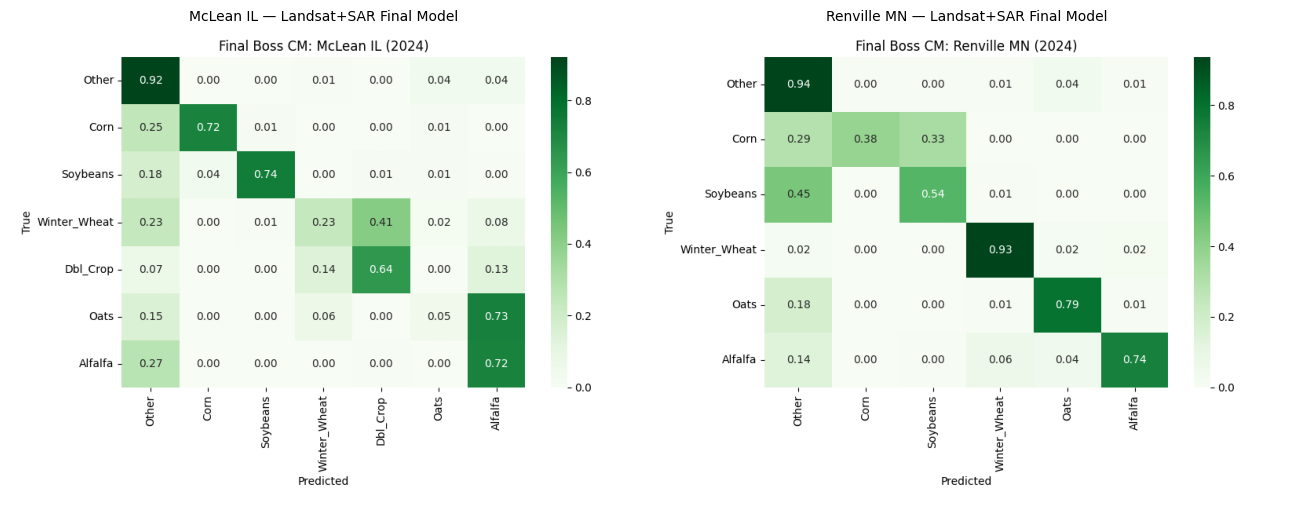

In [30]:
# Source: local_model_testing/cloud_and_cm_analysis.py
show(f'{LMT_OUT}/cloud_comparison.png', width=860)
show_side([f'{LMT_OUT}/final_cm_mclean.png', f'{LMT_OUT}/final_cm_renville.png'],
          titles=['McLean IL — Landsat+SAR Final Model', 'Renville MN — Landsat+SAR Final Model'])

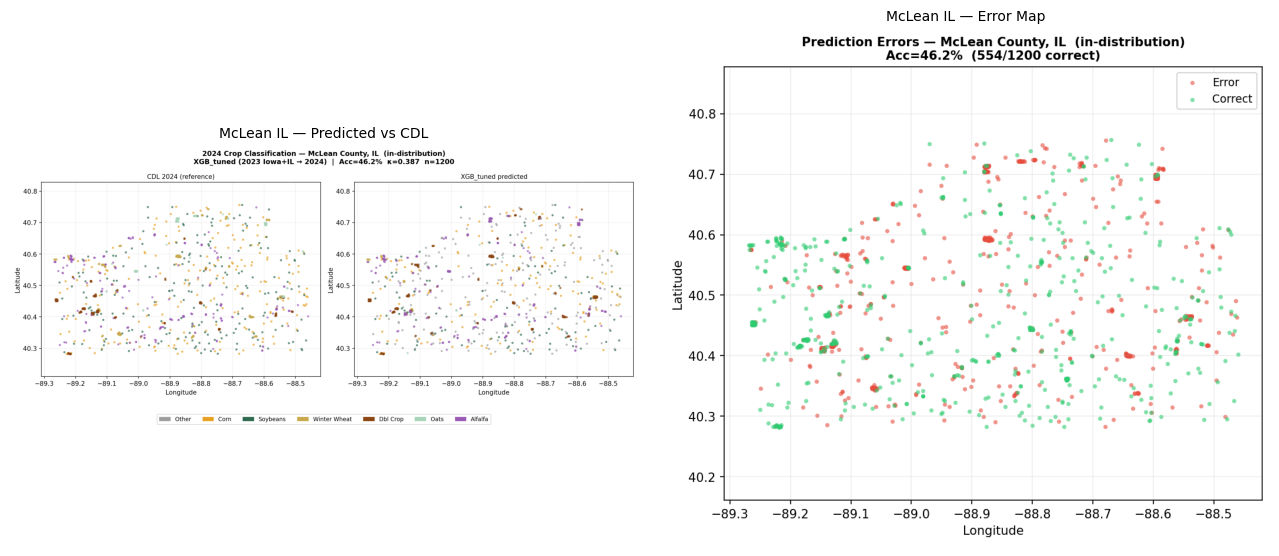

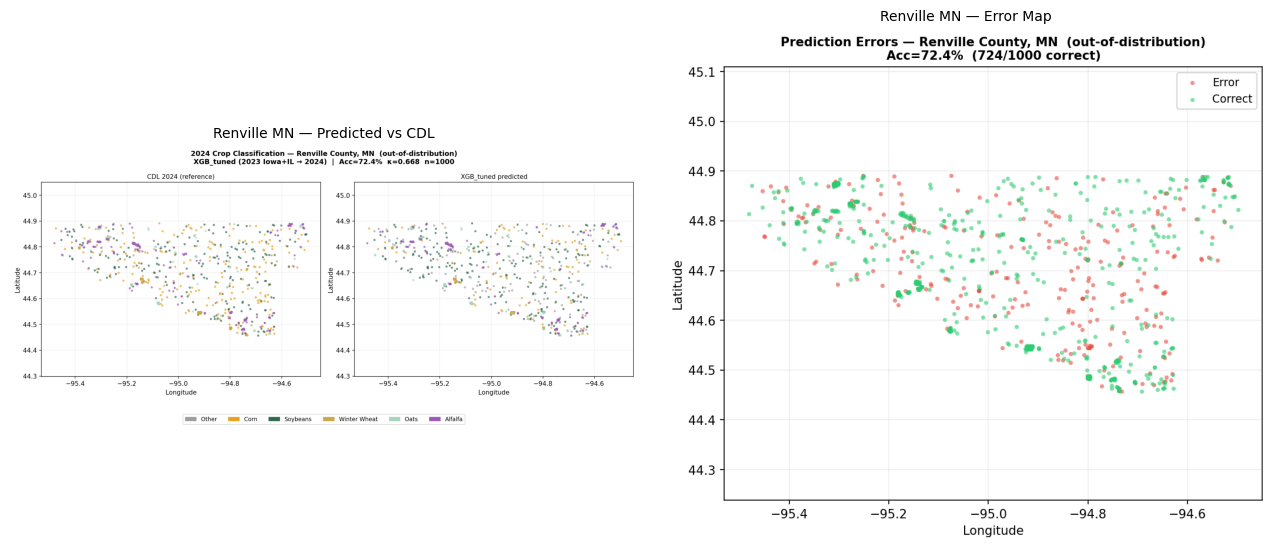

In [31]:
# Source: local_model_testing/plot_spatial_maps.py
show_side([f'{OUT}/phase4_mclean_spatial_map.png', f'{OUT}/phase4_mclean_error_map.png'],
          titles=['McLean IL — Predicted vs CDL', 'McLean IL — Error Map'])

show_side([f'{OUT}/phase4_renville_spatial_map.png', f'{OUT}/phase4_renville_error_map.png'],
          titles=['Renville MN — Predicted vs CDL', 'Renville MN — Error Map'])

---
## Summary and Conclusions

### Results Summary

| Component | Result |
|-----------|--------|
| GEE RF v4 (2023 test, 5 classes) | **87.2%**, κ = 0.838 |
| Local XGB base (2023 test, 7 classes) | 90.3%, κ = 0.838 |
| Local XGB + class weights (7 classes) | **90.7%**, κ = 0.846 |
| XGB + class weights + 2022 boost | 87.8%, κ = 0.831 (harder test set) |
| McLean IL 2024 (Landsat only) | 44–56% (cloud-limited) |
| McLean IL 2024 (+ SAR) | **59%**, +15% recovery |
| Alfalfa recall (2023 only → boosted) | 63% → **78%** |
| Oats recall (2023 only → boosted) | 69% → **86%** |

### Key Insights

**1. Phenology drives feature engineering.** Every meaningful accuracy gain in Phase 3 traces back to a phenological insight from Phase 2 — harmonic features for curve shape, LSWI for alfalfa water retention, full-year composites for late-season senescence timing. Feature engineering disconnected from domain knowledge produced no gain (v2→v3 harmonics alone).

**2. The Other class is not optional.** A 5-class model deployed over a real landscape assigns every non-crop pixel to the nearest crop class. Including Other is a basic requirement for any deployment scenario, not an enhancement.

**3. Fix the data before tuning the model.** Class weights outperformed 60 Optuna hyperparameter trials. Adding 2022 data fixed rare-class recall more than any regularization technique. SAR fusion recovered 15% accuracy in a cloud year. In every case, the binding constraint was data design, not model complexity.

**4. Generalization failures are diagnosable.** McLean and Renville failed for different reasons — cloud contamination vs. phenological lag. Treating them as one "generalization problem" would have led to the wrong interventions. Diagnosing each failure independently pointed to targeted solutions (SAR fusion for clouds; GDD normalization for spatial shift).

### Paths to Further Improvement
- Replace calendar-month composites with growing-degree-day-normalized windows to address phenological lag across counties and years
- Train on 2021–2023 data to cover a broader range of weather patterns
- Explore Sentinel-2 (10m) to reduce field-edge confusion
- In-season prediction using features through July only: v5 baseline achieves 80.1% — a practical early-season crop forecast is within reach